> 📖 Book: [ch02 – Eigen, SVD](../../.claude/skills/ml-knowledge/chapters/ch02-linear-algebra-eigen-svd.md) · Prev: [03](03_linear_inversion_problem.ipynb) · Next: [01_linear_regression](../01_linear_regression/01_normal_equations.ipynb)

# Singular Value Decomposition

## Introduction

In the domains of science and engineering, acquired data emanating from simulations and experiments are frequently encapsulated within vectors denoted as $\mathbf{x}_k \in \mathbb{C}^n$, where the subscript $k$ designates the label corresponding to the $k$-th distinct measurement. To elucidate, $\mathbf{x}_k$ might embody diverse representations, such as an image reshaped into a column vector, the state of a physical system at time point $k$ during its temporal evolution, or a time series $\mathbf{x}_k = x(k \Delta t)$. Consequently, the collated data is often organized into a comprehensive dataset $\mathbf{X} \in \mathbb{C}^{n \times m}$.

This dataset assumes the form:

$$
\mathbf{X} = 
\begin{bmatrix}
\mid & \mid & & \mid \\
\mathbf{x}_1 & \mathbf{x}_2 & \cdots & \mathbf{x}_m\\
\mid & \mid & & \mid \\
\end{bmatrix}
$$

In numerous instances, the dimensionality of the state, denoted by $n$, is notably extensive, frequently manifesting itself in orders of millions or billions of degrees of freedom. The individual columns within $\mathbf{X}$ are conventionally termed "snapshots," and $m$ signifies the count of these snapshots within the matrix. Often, the scenario unfolds where $n \gg m$, leading to a matrix that is vertically elongated or "tall and skinny," in contrast to instances when $n \ll m$," which result in a matrix that is relatively wider or "short and fat."

## The singular value decomposition

The singular value decomposition (SVD) is a distinctive matrix decomposition that exists for any complex-valued matrix $\mathbf{X} \in \mathbb{C}^{n \times m}$:

$$
\mathbf{X} = U \Sigma V^*,
$$

where $\mathbf{U} \in \mathbb{C}^{n \times n}$ and $\mathbf{V} \in \mathbb{C}^{m \times m}$ denote unitary matrices with orthonormal columns. The unitary condition entails $\mathbf{U} \mathbf{U}^* = \mathbf{U}^* \mathbf{U} = \mathbf{I}$ and $\mathbf{V} \mathbf{V}^* = \mathbf{V}^* \mathbf{V} = \mathbf{I}$. Both matrices $\mathbf{U}$ and $\mathbf{V}$ adhere to this unitarity condition. The matrix $\Sigma \in \mathbb{R}^{n \times m}$ comprises real, non-negative entries along the diagonal and zeros elsewhere. In this context, $\mathbf{I}$ denotes the identity matrix, while the symbol $^*$ signifies the complex conjugate transpose operation.

When $n \geq m$, the matrix $\Sigma$ features a maximum of $m$ non-zero elements on its diagonal, and can be expressed as:

$$
\Sigma = 
\begin{bmatrix}
\hat{\Sigma} \\
\bm{0}
\end{bmatrix}.
$$

Hence, a precise representation of $X$ can be achieved via the "economy" SVD:

$$
\mathbf{X} = \mathbf{U} \Sigma \mathbf{V}^* =
\begin{bmatrix}
\hat{\mathbf{U}} & \hat{\mathbf{U}}^\perp
\end{bmatrix}
\begin{bmatrix}
\hat{\Sigma} \\
\bm{0}
\end{bmatrix}
\mathbf{V}^* = 
\hat{\mathbf{U}} \hat{\Sigma} \mathbf{V}^*,
$$

where the columns of $\hat{\mathbf{U}}^\perp$ span a vector space that is orthogonal and supplementary to the space spanned by $\hat{\mathbf{U}}$. The columns of matrix $\mathbf{U}$ are termed the left singular vectors of $\mathbf{X}$, while the columns of matrix $\mathbf{V}$ represent the right singular vectors. The diagonal entries of $\hat{\Sigma} \in \mathbb{R}^{m \times m}$ are denoted as singular values, and they are arranged in descending order. The rank of matrix $\mathbf{X}$ coincides with the count of non-zero singular values.

## SVD Computation

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.image import imread

from ml.linalg import energy, low_rank_approx
from ml.utils.paths import data_raw_dir

plt.style.use("seaborn-v0_8-whitegrid")
rng = np.random.default_rng(0)

X = rng.random((10, 3))
Uhat, Shat, VT = np.linalg.svd(X, full_matrices=False)  # economy SVD
print("shapes:", Uhat.shape, Shat.shape, VT.shape)
print("singular values:", Shat)
print("X == U S V^T:", np.allclose(X, Uhat @ np.diag(Shat) @ VT))

shapes: (10, 3) (3,) (3, 3)
singular values: [3.03769663 1.19918042 0.95477153]
X == U S V^T: True


## Matrix Approximation

As importan attribute of the Singular Value Decomposition (SVD) is its capacity to offer an optimal approximation of reduced rank to a matrix $\mathbf{X}$. With the stratification of low-rank approximations intrinsic to the SVD framework, a rank-$r$ approximation is realized through the retention of the foremost $r$ singular values and their corresponding vectors, while discarding the remaining components. The matrix $\mathbf{X} = \mathbf{U} \Sigma \mathbf{V}^*$ can be equivalently expressed as a summation of rank-one matrices:

$$
\mathbf{X} = \sum_{k=1}^m \sigma_k \mathbf{u}_k \mathbf{v}_k^* = \sigma_1 \mathbf{u}_1 \mathbf{v}_1^* + \sigma_2 \mathbf{u}_2 \mathbf{v}_2^* + \cdots + \sigma_m \mathbf{u}_m \mathbf{v}_m^*,
$$

where $\sigma_k$ corresponds to the $k$-th diagonal element of $\Sigma$, and $\mathbf{u}_k$ and $\mathbf{v}_k$ signify the $k$-th columns of matrices $\mathbf{U}$ and $\mathbf{V}$ respectively. These singular values $\sigma_k$ exhibit a decreasing sequence: $\sigma_1 \geq \sigma_2 \geq \cdots \geq \sigma_m \geq 0$. As such, each subsequent rank-one matrix $\sigma_k \mathbf{u}_k \mathbf{v}_k^*$ becomes progressively less influential in encapsulating the information embodied within matrix $\mathbf{X}$. In many system contexts, the singular values $\sigma_k$ exhibit rapid diminishment, facilitating the acquisition of a favorable approximation of $\mathbf{X}$ through truncation at a specified rank $r$:

$$
\mathbf{X} \approx \tilde{\mathbf{X}} = \sum_{k=1}^r \sigma_k \mathbf{u}_k \mathbf{v}_k^* = \sigma_1 \mathbf{u}_1 \mathbf{v}_1^* + \sigma_2 \mathbf{u}_2 \mathbf{v}_2^* + \cdots + \sigma_r \mathbf{u}_r \mathbf{v}_r^*.
$$

The resultant approximated matrix is denoted as:

$$
\tilde{\mathbf{X}} = \tilde{\mathbf{U}} \tilde{\Sigma} \tilde{\mathbf{V}}^*,
$$

where $\tilde{\mathbf{U}} \in \mathbb{R}^{n \times r}$, $\tilde{\Sigma} \in \mathbb{R}^{r \times r}$, and $\tilde{\mathbf{V}} \in \mathbb{R}^{m \times r}$.

### Example: Image Compression

A shape: (2000, 1500, 3) -> X shape: (2000, 1500)


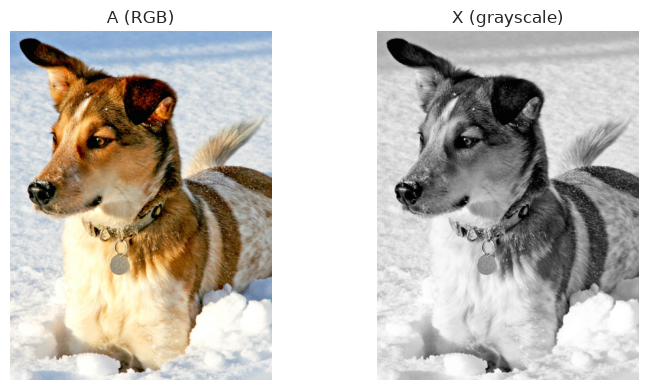

In [2]:
A = imread(data_raw_dir("images", "dog.jpg"))
X = A.mean(axis=-1)  # grayscale: mean of the R, G, B channels
print("A shape:", A.shape, "-> X shape:", X.shape)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(A)
ax[1].imshow(X, cmap="gray")
ax[0].set_title("A (RGB)")
ax[1].set_title("X (grayscale)")
for a in ax:
    a.axis("off")
fig.tight_layout()
plt.show()

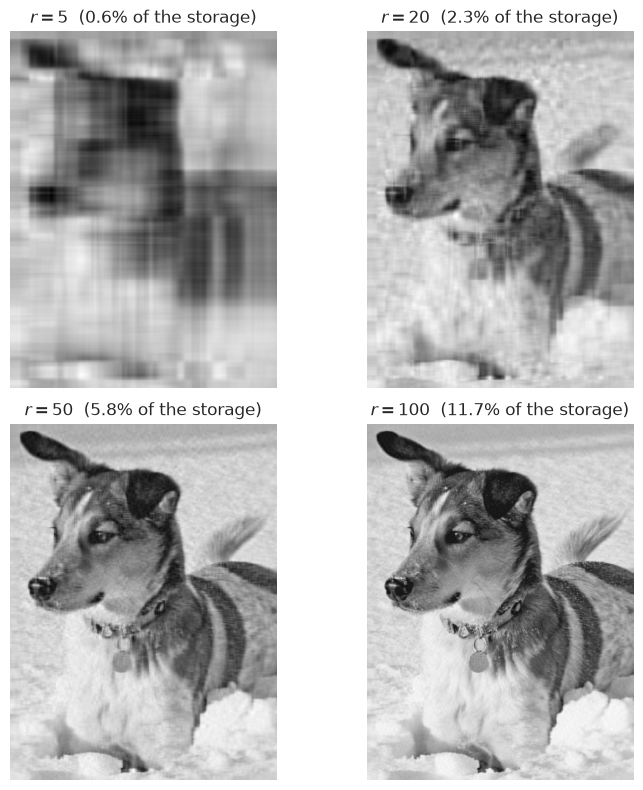

In [3]:
ranks = [5, 20, 50, 100]
fig, ax = plt.subplots(2, 2, figsize=(8, 8))
for a, r in zip(ax.ravel(), ranks, strict=True):
    a.imshow(low_rank_approx(X, r), cmap="gray")
    storage = r * (X.shape[0] + X.shape[1] + 1) / X.size
    a.set_title(f"$r = {r}$  ({storage:.1%} of the storage)")
    a.axis("off")
fig.tight_layout()
plt.show()

In [4]:
s = np.linalg.svd(X, compute_uv=False)
e = energy(s)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].semilogy(s)
ax[0].set(xlabel="$k$", ylabel=r"$\sigma_k$", title="singular values")
ax[1].plot(e)
for level in (0.9, 0.99):
    k = int(np.searchsorted(e, level)) + 1
    ax[1].axhline(level, ls="--", c="gray")
    ax[1].annotate(f"{level:.0%} energy: r = {k}", (k, level), xytext=(k + 30, level - 0.08), arrowprops={"arrowstyle": "->"})
ax[1].set(xlabel="$r$", ylabel=r"$\sum_{k \le r}\sigma_k^2 / \sum_k \sigma_k^2$", title="cumulative energy")
plt.show()

ValueError: 
\sum_{k \le r}\sigma_k^2 / \sum_k \sigma_k^2
        ^
ParseSyntaxException: Unknown symbol: \le, found '\'  (at char 8), (line:1, col:9)

<Figure size 1100x400 with 2 Axes>

### Example: 12-lead ECG

Each of the 12 leads of an electrocardiogram records the same heartbeat from a different angle, so the leads are highly correlated. Stacking them as rows of a $12 \times T$ matrix, the SVD finds a handful of orthogonal time patterns (rows of $V^T$) that explain almost all the signal.

In [5]:
ecg = np.load(data_raw_dir("ecg12-500hzsrfava.npy"))
print("ECG shape (samples, leads):", ecg.shape)

ECG shape (samples, leads): (5000, 12)


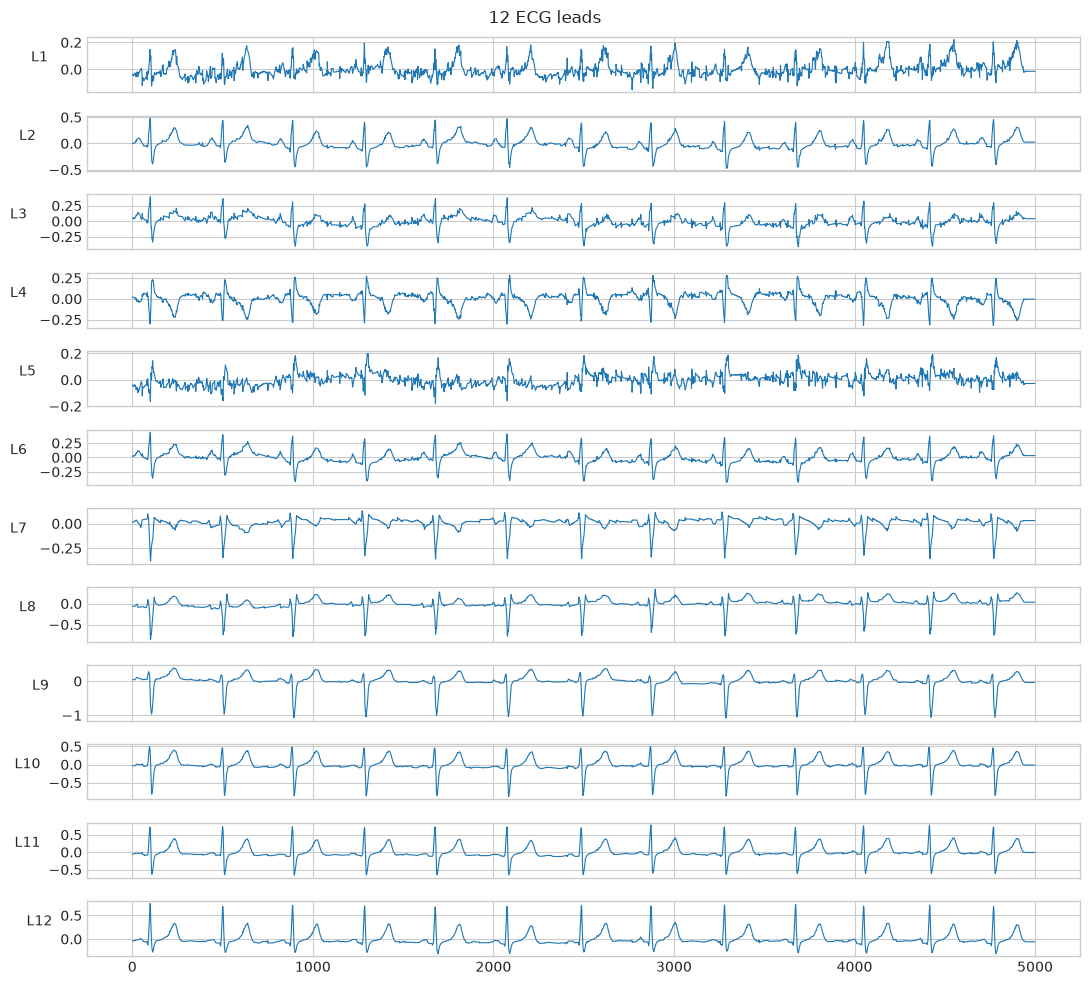

In [6]:
fig, ax = plt.subplots(ecg.shape[1], 1, figsize=(11, 10), sharex=True)
for i in range(ecg.shape[1]):
    ax[i].plot(ecg[:, i].ravel(), lw=0.8)
    ax[i].set_ylabel(f"L{i + 1}", rotation=0, labelpad=15)
fig.suptitle("12 ECG leads")
plt.tight_layout()
plt.show()

In [7]:
Uhat, Shat, VThat = np.linalg.svd(ecg.T, full_matrices=False)
print("U:", Uhat.shape, "S:", Shat.shape, "V^T:", VThat.shape)
print("energy captured by the first 3 modes:", energy(Shat)[:3].round(3))

U: (12, 12) S: (12,) V^T: (12, 5000)
energy captured by the first 3 modes: [0.724 0.927 0.973]


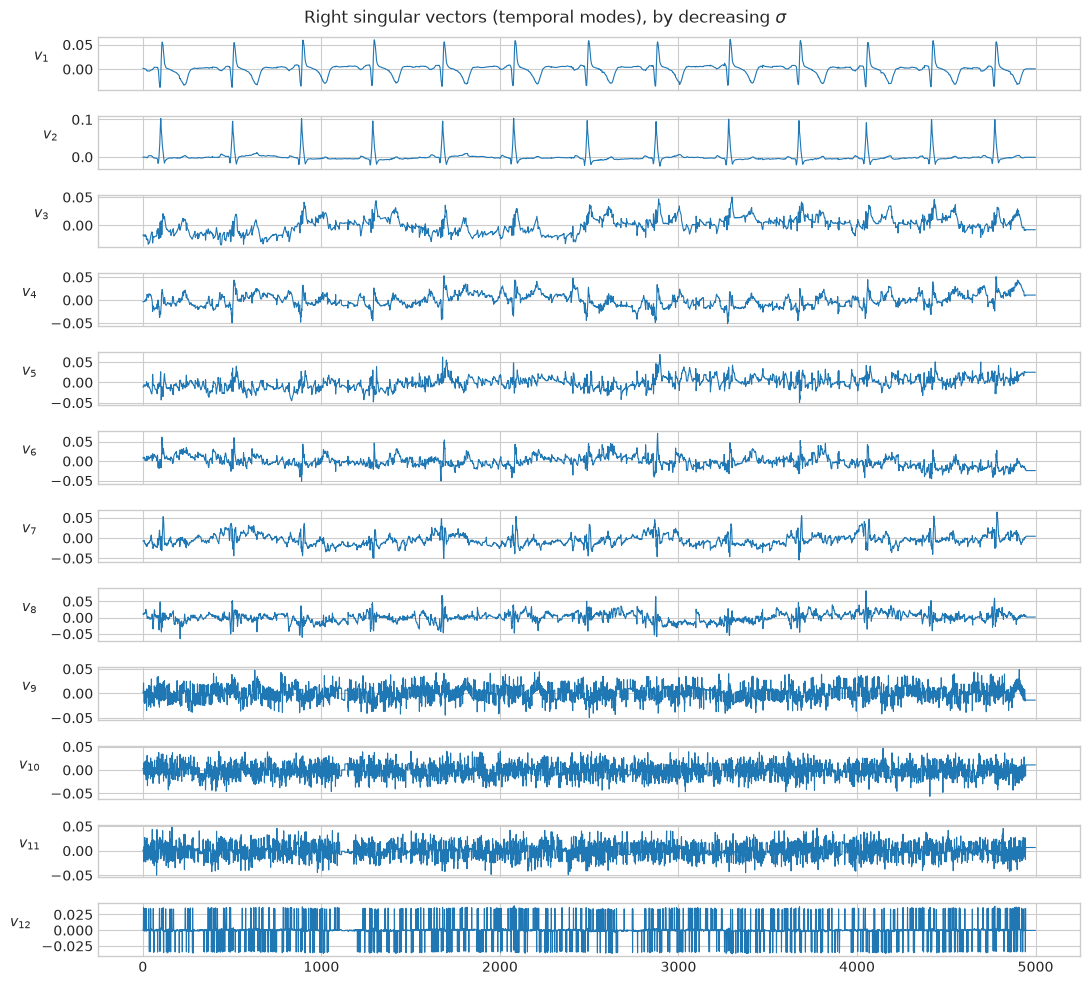

In [8]:
fig, ax = plt.subplots(12, 1, figsize=(11, 10), sharex=True)
for i in range(12):
    ax[i].plot(VThat[i, :].ravel(), lw=0.8)
    ax[i].set_ylabel(f"$v_{{{i + 1}}}$", rotation=0, labelpad=15)
fig.suptitle("Right singular vectors (temporal modes), by decreasing $\\sigma$")
plt.tight_layout()
plt.show()